In [550]:
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
importlib.reload(deep_learning.model)
from deep_learning.model import Perceptron #import my implmentation

In [551]:
# Iris dataset : The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
urllib.request.urlretrieve(url, "iris.csv")  # download
data = np.genfromtxt("iris.csv", delimiter=",", dtype=str)  # read
SETOSA = "Iris-setosa"
VERSICOLOR = "Iris-versicolor"
mask = (data[:, 4] == SETOSA) | (data[:, 4] == VERSICOLOR) # first two classes
data = data[mask]
class_names = np.unique(data[:, 4]) # ['Iris-setosa', 'Iris-versicolor']

In [552]:
X = data[:, 0:4].astype(float)
y = (data[:, 4] == class_names[1]).astype(int)

In [553]:
SEED = 24


def train_test_split(X, y, test_size=0.2, seed=None):
    rng = np.random.default_rng(seed=seed)
    indexes = rng.permutation(len(X))
    n_test = int(len(X) * test_size)
    return (
        X[indexes[n_test:]], X[indexes[:n_test]],
        y[indexes[n_test:]], y[indexes[:n_test]],
        )


(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)

In [554]:
# normalization by feature
X_min, X_max = X_train.min(axis=0), X_train.max(axis=0) # row colapse
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

In [555]:
def plot_learning_curve(errors):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(errors) + 1), errors, marker='o', color='b')
    plt.title('Error evolution (Learning Curve)')
    plt.xlabel('Epochs')
    plt.ylabel('Number of misclassifications')
    plt.grid(True)
    plt.show()


def plot_heatmap(perceptron):
    w = perceptron.w.reshape(1, -1)
    vmax = np.abs(w).max()
    plt.figure(figsize=(10, 1))
    plt.imshow(w, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.yticks([])
    plt.title("Perceptron weights")
    plt.show()

In [563]:
EPOCHS = 125
LR = 0.0005
model = Perceptron(X.shape[1], lr=LR, seed=SEED)
errors = model.train(X_train, y_train, epochs=EPOCHS)
for index, epoch_error in enumerate(errors):
    print(f"Epoch: {index+1} | Errores: {epoch_error}")

Epoch: 1 | Errores: 46
Epoch: 2 | Errores: 10
Epoch: 3 | Errores: 4
Epoch: 4 | Errores: 2
Epoch: 5 | Errores: 2
Epoch: 6 | Errores: 1
Epoch: 7 | Errores: 0


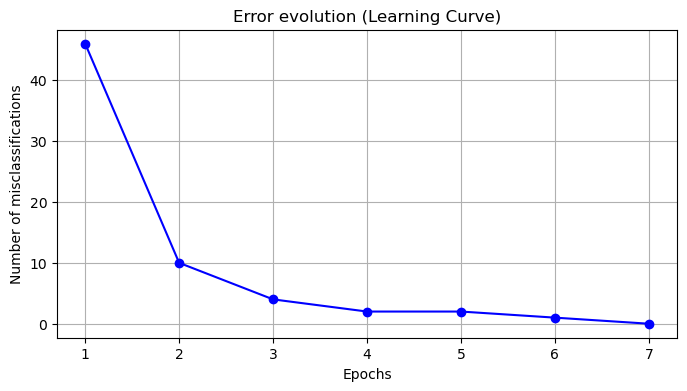

In [564]:
plot_learning_curve(errors)

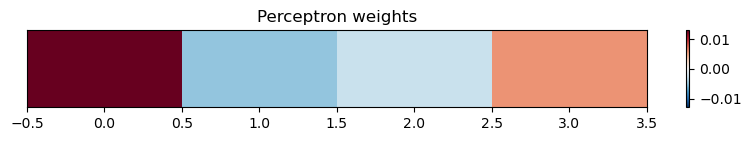

In [565]:
plot_heatmap(model)

In [566]:
for xi, yi in zip(X_test, y_test):
    pred = model.predict(xi)
    print(f"true: {class_names[yi]}  prediction: {class_names[pred]}")

true: Iris-setosa  prediction: Iris-setosa
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-setosa  prediction: Iris-setosa
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-setosa  prediction: Iris-setosa
true: Iris-setosa  prediction: Iris-setosa


In [567]:
accuracy = np.mean(model.predict(X_test) == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%
